# V1 decision stack against the frozen candidate library

> **Main question.** Given a raw transaction and a frozen, training-built candidate library, can we pick a small
> number of pack sends with a meaningfully higher probability of capturing an out-of-sample arb?

```text
raw tx -> relevance gate (relevance-v1) -> framed-tx-v2 -> txflat-v2 -> arb classifier
       -> candidate-library lookup (depth k) -> pack ranking -> send top 1-3
```

**Protocol.** Slots are split 70 / 15 / 15 in time order.
- **Train:** the candidate library (`candidate-packs build-library`), the arb classifier and the pack ranker are all built
  from train only.
- **Validation:** chooses thresholds, send budgets, depth k and live top-L. The library stays frozen.
- **Test:** evaluated once.

The notebook stops if the library's training window extends past the train split.

**Sections.**
1. Data and protocol checks
2. Classifier quality
3. Library availability against depth k
4. Route-recurrence ceiling
5. Static vs ML pack ranking
6. Joint score vs two-stage decisions, at matched send budgets
7. Failure decomposition and conditional results
8. Artifacts

In [1]:
import json, os
from pathlib import Path

import numpy as np
import polars as pl
from IPython.display import Markdown, display

from firm_ml import data, encoding, metrics, models, plots, policy, splits

PREPARED = Path(os.environ.get("FIRM_ML_PREPARED", "D:/firm-ml/prepared/p045v2-library"))   # library catalog
LEGACY = os.environ.get("FIRM_ML_LEGACY", "D:/firm-ml/prepared/p045v2-legacy")              # legacy catalog ("" to skip)
EXPERIMENT = os.environ.get("FIRM_ML_EXPERIMENT", "v1-p045-library-ftx2")
RUN_DIR = Path(os.environ.get("FIRM_ML_RUNS", "../runs")).resolve() / EXPERIMENT
PLOTS = RUN_DIR / "plots"; PLOTS.mkdir(parents=True, exist_ok=True)

SPLIT_FRACTIONS = (0.70, 0.15, 0.15)
DEPTHS = [3, 5, 8, 16, 32, 64]          # library depth k
LIVE_TOP = [1, 2, 3]                    # packs sent per decision
BUDGETS = [250, 1000, 4000, 16000]      # sends per chain hour; thresholds are fitted to these on validation
GATE = "relevant"

plots.style()
pl.Config.set_tbl_rows(60); pl.Config.set_tbl_cols(30); pl.Config.set_fmt_str_lengths(50); pl.Config.set_tbl_width_chars(240)
prep = data.open_prepared(PREPARED)
M = prep.manifest
PPM = M["config"]["unknown_pair_ppm"]
RESULTS = {"experiment": EXPERIMENT, "prepared": str(PREPARED), "legacy": LEGACY or None}
print(PREPARED, M["schemas"]["pack_catalog"], M["packs"]["count"], "packs ->", RUN_DIR)

D:\firm-ml\prepared\p045v2-library candidate-library-v1 27496 packs -> C:\Users\louis\Desktop\the-firm-offline\ml\runs\v1-p045-library-ftx2


## 1. Data and protocol checks

In [2]:
tx = data.load_transactions(prep)
pairs = data.load_pairs(prep)
packs = data.load_packs(prep)

bounds = splits.slot_boundaries(tx["slot"], SPLIT_FRACTIONS)
tx = splits.assign_split(tx, bounds)
splits.check_disjoint(tx)
pairs = pairs.join(tx.select("master_tx_id", "split"), on="master_tx_id", how="left")
assert pairs["split"].null_count() == 0
splits.check_disjoint(pairs)
ids = {s: (int(g["master_tx_id"].min()), int(g["master_tx_id"].max())) for (s,), g in tx.group_by("split")}

# Frozen-library protocol: the catalog (and every train_meta feature) comes from train master ids only.
pw = M["packs"]
assert pw["train_master_tx_id_min"] is not None and ids["train"][0] <= pw["train_master_tx_id_min"]
assert pw["train_master_tx_id_max"] <= ids["train"][1], f"library window {pw} extends past train {ids['train']}"

legacy = None
if LEGACY:
    legacy = data.open_prepared(LEGACY)
    data.check_same_labels(prep, legacy)
    lw = legacy.manifest["packs"]
    assert lw["train_master_tx_id_max"] <= ids["train"][1], "legacy catalog is not train-only"

split_table = tx.group_by("split").agg(
    pl.len().alias("master_txs"), pl.col(GATE).sum().alias("relevant"),
    pl.col("arb_target").is_not_null().sum().alias("labelled"), (pl.col("arb_target") == 1).sum().alias("positives"),
    ((pl.col("arb_target") == 1) & (pl.col(GATE) == 1)).sum().alias("relevant_positives"),
    ((pl.col("block_time").max() - pl.col("block_time").min()) / 3600).alias("chain_hours"),
).sort("split")
HOURS = dict(zip(split_table["split"], split_table["chain_hours"]))
overview = {
    "dataset_id": M["config"]["dataset_id"], "master_txs": tx.height,
    "labels": dict(tx.group_by("arb_label").len().iter_rows()),
    "catalog": {k: pw[k] for k in ("catalog_schema", "count", "train_master_tx_id_min", "train_master_tx_id_max", "max_rank")},
    "library_config_sha256": (pw.get("library") or {}).get("config_sha256"),
    "master_id_windows": ids, "pairs": M["pairs"], "relevance_gate_pass_rate": float(tx[GATE].mean()),
    "raw_source": M["raw_source"]["kind"], "v1_format_txs": M["features"].get("v1_format"),
}
encoder = tx.group_by("arb_label").agg(pl.len().alias("txs"), (pl.col("encode_status") != 0).sum().alias("encoder_cannot_parse"),
                                       (pl.col("encode_status") != 0).mean().alias("share")).sort("arb_label")
RESULTS["encoder_coverage"] = encoder.to_dicts()
display(encoder)
RESULTS.update(overview=overview, splits={"boundaries": bounds, "table": split_table.to_dicts()})
display(split_table)
overview

arb_label,txs,encoder_cannot_parse,share
str,u32,u32,f64
"""CERTIFIED_NEGATIVE""",5175,0,0.0
"""POSITIVE""",1073,0,0.0
"""UNKNOWN""",403704,0,0.0


split,master_txs,relevant,labelled,positives,relevant_positives,chain_hours
str,u32,i64,u32,u32,u32,f64
"""test""",43359,35680,832,77,66,0.276111
"""train""",321673,270186,4641,928,586,1.300278
"""val""",44920,35433,775,68,55,0.276389


{'dataset_id': 'labeller-week-20260925-001/p045/library/framed-tx-v2',
 'master_txs': 409952,
 'labels': {'CERTIFIED_NEGATIVE': 5175, 'POSITIVE': 1073, 'UNKNOWN': 403704},
 'catalog': {'catalog_schema': 'candidate-library-v1',
  'count': 27496,
  'train_master_tx_id_min': 1,
  'train_master_tx_id_max': 321673,
  'max_rank': 63},
 'library_config_sha256': 'e82c7a07d8cb3ed74d082ccb9c53da272ee777234ae141a04c095b1c93aac303',
 'master_id_windows': {'train': (1, 321673),
  'val': (321674, 366593),
  'test': (366594, 409952)},
 'pairs': {'max_depth': 64,
  'positive_target': 86431,
  'rows': 9168203,
  'rule': 'POSITIVE: all-layer packs; CERTIFIED_NEGATIVE: live packs; UNKNOWN: live packs if relevant and pair_sample',
  'transactions': 46664,
  'unknown_pair_ppm': 125000},
 'relevance_gate_pass_rate': 0.8325340527671532,
 'raw_source': 'fleet-dataset-transactions-parquet',
 'v1_format_txs': 136441}

In [3]:
# Leakage checks: features come only from the manifest; ids, labels, meta and gate columns are refused;
# pack features are static structure or train-window library metadata (allowed because the window precedes val/test).
data.check_feature_columns(prep, prep.tx_features + prep.pack_features)
for bad in ["slot", "master_tx_id", "arb_target", "pack_target", "pack_rank", "builder_rank", "min_cover_rank_live",
            "n_profitable_routes_seen_in_train", "trigger_keys", GATE]:
    try:
        data.check_feature_columns(prep, [bad]); raise AssertionError(f"{bad} accepted as a feature")
    except ValueError:
        pass
groups = {f["group"] for f in prep.feature_manifest["pack_features"]}
assert groups <= {"static", "train_meta"}, groups
TRAIN_META = prep.pack_features_in("train_meta")
STATIC_PACK = prep.pack_features_in("static")
print(len(prep.tx_features), "tx features;", len(STATIC_PACK), "static pack features;", len(TRAIN_META), "train_meta:", TRAIN_META)

159 tx features; 30 static pack features; 13 train_meta: ['pack_library_rank', 'pack_selection_gain', 'pack_train_covered_txs', 'pack_train_new_txs', 'pack_train_cumulative_txs', 'pack_train_key_txs', 'pack_new_route_ids', 'pack_new_pools', 'pack_new_venue_sequences', 'pack_new_hop_counts', 'pack_shared_accounts', 'pack_route_support_min', 'pack_route_support_sum']


## 2. Classifier quality

LightGBM binary on transaction features only. POSITIVE = 1, CERTIFIED_NEGATIVE = 0, and UNKNOWN is excluded from the
loss. There is no reweighting. Early stopping uses validation PR-AUC. Quality is reported on relevant labelled
transactions, since that is the population the deployed gate passes.

split,population,n,positives,base_rate,pr_auc,roc_auc
str,str,i64,i64,f64,f64,f64
"""train""","""all labelled""",4641,928,0.199957,0.995809,0.998041
"""train""","""relevant labelled""",3848,586,0.152287,0.992962,0.997362
"""val""","""all labelled""",775,68,0.087742,0.776314,0.963121
"""val""","""relevant labelled""",682,55,0.080645,0.769146,0.967638
"""test""","""all labelled""",832,77,0.092548,0.622122,0.894212
"""test""","""relevant labelled""",728,66,0.090659,0.626462,0.898425


shuffled-label control, val: {'n': 775, 'positives': 68, 'base_rate': 0.08774193548387096, 'pr_auc': 0.22125814982552022, 'roc_auc': 0.5554642649138863}


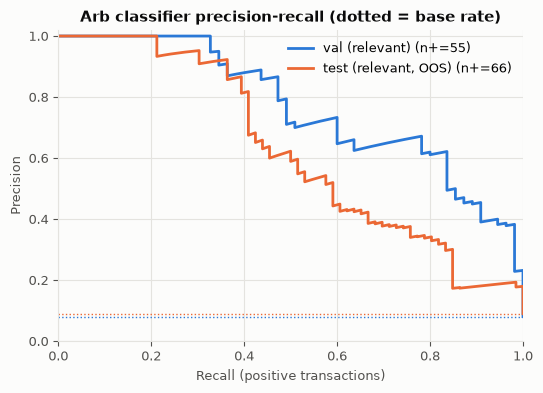

In [4]:
lab = data.arb_training_rows(tx)
arb_enc = encoding.FeatureEncoder(prep.tx_features, prep.kinds).fit(lab.filter(pl.col("split") == "train"))
part = {s: lab.filter(pl.col("split") == s) for s in splits.SPLITS}
X = {s: arb_enc.transform(part[s]) for s in splits.SPLITS}
Y = {s: part[s]["arb_target"].to_numpy() for s in splits.SPLITS}
G = {s: part[s][GATE].to_numpy() == 1 for s in splits.SPLITS}
arb = models.train_binary(X["train"], Y["train"], X["val"], Y["val"], arb_enc, models.ARB_PARAMS)
P = {s: arb.predict(X[s], num_iteration=arb.best_iteration) for s in splits.SPLITS}
tx = tx.with_columns(pl.Series("arb_score", arb.predict(arb_enc.transform(tx), num_iteration=arb.best_iteration)))

rows = []
for s in splits.SPLITS:
    for pop, m in (("all labelled", np.ones_like(G[s])), ("relevant labelled", G[s])):
        r = metrics.classifier_summary(Y[s][m], P[s][m]); r.update(split=s, population=pop); rows.append(r)
arb_summary = pl.DataFrame(rows).select("split", "population", "n", "positives", "base_rate", "pr_auc", "roc_auc")
rng = np.random.default_rng(7)
ctrl = models.train_binary(X["train"], rng.permutation(Y["train"]), X["val"], Y["val"], arb_enc, models.ARB_PARAMS, rounds=300, early_stopping=50)
RESULTS["arb"] = {"best_iteration": arb.best_iteration, "summary": arb_summary.to_dicts(),
                  "shuffled_label_control_val": metrics.classifier_summary(Y["val"], ctrl.predict(X["val"], num_iteration=ctrl.best_iteration)),
                  "importance": models.importance(arb)[:30]}
plots.pr_curves({"val (relevant)": (Y["val"][G["val"]], P["val"][G["val"]]),
                 "test (relevant, OOS)": (Y["test"][G["test"]], P["test"][G["test"]])},
                "Arb classifier precision-recall (dotted = base rate)", PLOTS / "arb_pr_curve.png")
display(arb_summary)
print("shuffled-label control, val:", RESULTS["arb"]["shuffled_label_control_val"])

## 3. Library OOS availability against depth k

**Availability** at depth k is the share of positive transactions for which some eligible pack among the first k of
its key covers one of their profitable RouteIds.
- **Live:** TOP_LEVEL keys only.
- **Oracle:** all layers.

The oracle column must equal the library repo's own `sweep-library` result (`positive_tx_coverage`) on the same
master-id windows. This cross-checks the RouteId coverage semantics across the two repos.

sweep,k,library_repo,ml_prep,txs_library_repo,txs_ml_prep
str,i64,f64,f64,i64,i64
"""sweep-legacy-test.json""",1,0.233766,0.233766,18,18
"""sweep-legacy-test.json""",2,0.298701,0.298701,23,23
"""sweep-legacy-test.json""",3,0.324675,0.324675,25,25
"""sweep-legacy-test.json""",5,0.324675,0.324675,25,25
"""sweep-legacy-test.json""",8,0.324675,0.324675,25,25
"""sweep-legacy-test.json""",16,0.324675,0.324675,25,25
"""sweep-legacy-test.json""",32,0.324675,0.324675,25,25
"""sweep-legacy-test.json""",64,0.324675,0.324675,25,25
"""sweep-legacy-val.json""",1,0.294118,0.294118,20,20


split,catalog,eligibility,3,5,8,16,32,64
str,str,str,f64,f64,f64,f64,f64,f64
"""test""","""legacy""","""live""",0.220779,0.220779,0.220779,0.220779,0.220779,0.220779
"""test""","""legacy""","""oracle""",0.324675,0.324675,0.324675,0.324675,0.324675,0.324675
"""test""","""library""","""live""",0.194805,0.233766,0.272727,0.311688,0.363636,0.376623
"""test""","""library""","""oracle""",0.324675,0.324675,0.337662,0.350649,0.402597,0.415584
"""val""","""legacy""","""live""",0.323529,0.323529,0.323529,0.323529,0.323529,0.323529
"""val""","""legacy""","""oracle""",0.397059,0.397059,0.397059,0.397059,0.397059,0.397059
"""val""","""library""","""live""",0.323529,0.323529,0.367647,0.426471,0.470588,0.529412
"""val""","""library""","""oracle""",0.397059,0.397059,0.426471,0.455882,0.529412,0.573529


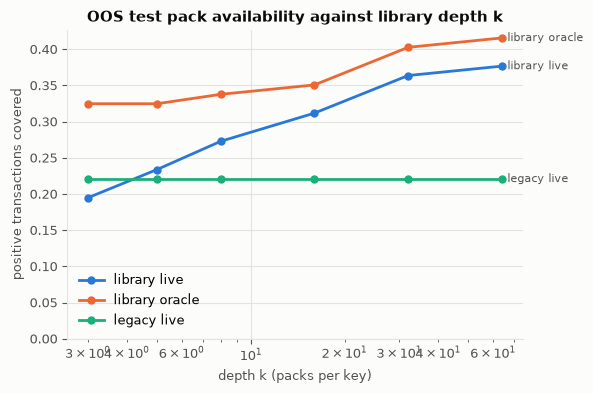

In [5]:
rows = []
for s in ("val", "test"):
    t = tx.filter(pl.col("split") == s)
    for mode in ("live", "oracle"):
        for r in policy.availability(t, DEPTHS + [1, 2], mode).iter_rows(named=True):
            rows.append({"split": s, "catalog": "library", "eligibility": mode, **r})
    if legacy is not None:
        lt = data.load_transactions(legacy).select("master_tx_id", "slot", "arb_target", "min_cover_rank_live", "min_cover_rank_oracle")
        lt = splits.assign_split(lt, bounds).filter(pl.col("split") == s)
        for mode in ("live", "oracle"):
            for r in policy.availability(lt, DEPTHS + [1, 2], mode).iter_rows(named=True):
                rows.append({"split": s, "catalog": "legacy", "eligibility": mode, **r})
avail = pl.DataFrame(rows).sort("split", "catalog", "eligibility", "k")
RESULTS["availability"] = avail.to_dicts()

# Cross-check against the library repo's sweep (embedded as provenance by ml-prep).
checks = []
for name, entry in M["provenance"].items():
    if not name.startswith("sweep-"):
        continue
    catalog, split = name.removeprefix("sweep-").removesuffix(".json").split("-")
    for row in entry["content"]["sweep"]:
        mine = avail.filter((pl.col("split") == split) & (pl.col("catalog") == catalog) & (pl.col("eligibility") == "oracle") & (pl.col("k") == row["k"]))
        if mine.height:
            checks.append({"sweep": name, "k": row["k"], "library_repo": row["positive_tx_coverage"], "ml_prep": mine["availability"][0],
                           "txs_library_repo": row["positive_txs_covered"], "txs_ml_prep": mine["available"][0]})
checks = pl.DataFrame(checks)
RESULTS["sweep_cross_check"] = checks.to_dicts()
display(checks)
assert checks.height and (checks["txs_library_repo"] == checks["txs_ml_prep"]).all(), "coverage disagrees with sweep-library"

curves = {f"{c} {m}": (avail.filter((pl.col("split") == "test") & (pl.col("catalog") == c) & (pl.col("eligibility") == m) & pl.col("k").is_in(DEPTHS)))
          for c, m in [("library", "live"), ("library", "oracle"), ("legacy", "live")] if c == "library" or legacy is not None}
plots.lines({n: (d["k"].to_list(), d["availability"].to_list()) for n, d in curves.items()},
            "OOS test pack availability against library depth k", "depth k (packs per key)", "positive transactions covered",
            PLOTS / "availability_vs_k.png", logx=True)
avail.filter(pl.col("k").is_in(DEPTHS)).pivot(on="k", index=["split", "catalog", "eligibility"], values="availability")

## 4. Route-recurrence ceiling

A pack can only cover RouteIds that it contains, and a frozen library only contains routes that were profitable in
training. The share of positives with *any* profitable RouteId seen among train positives therefore bounds what pack
retention can achieve.

In [6]:
pos = tx.filter(pl.col("arb_target") == 1).with_columns(
    (pl.col("n_profitable_routes_seen_in_train") > 0).alias("route_seen"),
    (pl.col("min_cover_rank_oracle") < 64).fill_null(False).alias("covered_oracle_64"),
    (pl.col("min_cover_rank_live") < 64).fill_null(False).alias("covered_live_64"))
ceiling = pos.group_by("split").agg(
    pl.len().alias("positives"), pl.col("route_seen").sum().alias("route_seen_in_train"),
    pl.col("route_seen").mean().alias("ceiling"),
    pl.col("covered_oracle_64").sum().alias("covered_oracle_k64"), pl.col("covered_live_64").sum().alias("covered_live_k64"),
    (pl.col("covered_live_64") & pl.col("route_seen")).sum().alias("covered_live_given_seen"),
).sort("split")
RESULTS["route_recurrence"] = ceiling.to_dicts()
ceiling

split,positives,route_seen_in_train,ceiling,covered_oracle_k64,covered_live_k64,covered_live_given_seen
str,u32,u32,f64,u32,u32,u32
"""test""",77,54,0.701299,32,29,29
"""train""",928,928,1.0,749,749,749
"""val""",68,58,0.852941,39,36,36


## 5. Pack ranking: static vs learned

Each pair row is `transaction features + pack features`, and the target is whether the pack covers a profitable
RouteId of that transaction. The ranker is trained on the live pairs of POSITIVE train transactions (depth 64) and
early-stopped on validation.

Its output, P(pack covers | arb, tx, pack), is the pack term of the joint score.

Scorers compared, all deterministic, with ties broken by catalog rank and then pack id:

| scorer | rule |
|---|---|
| `library_static` | library rank |
| `legacy_static` | legacy builder rank, using the legacy catalog's own pairs |
| `ml` | learned |
| `ml_static_only` | learned, without the library's train_meta features (ablation) |
| `random` | seeded random |

**Keep rule:** the learned ranker is kept only if its validation top-1 beats `library_static` at depth 64.

In [7]:
rf = data.ranker_frame(prep, tx, pairs, packs)
train_rows = rf.filter((pl.col("arb_label") == "POSITIVE") & pl.col("eligible_live"))
def fit_ranker(cols):
    data.check_feature_columns(prep, cols)
    enc = encoding.FeatureEncoder(cols, prep.kinds).fit(train_rows.filter(pl.col("split") == "train"))
    tr, va = (train_rows.filter(pl.col("split") == s) for s in ("train", "val"))
    m = models.train_binary(enc.transform(tr), tr["pack_target"].to_numpy(), enc.transform(va), va["pack_target"].to_numpy(),
                            enc, models.RANKER_PARAMS)
    return m, enc
ranker, rk_enc = fit_ranker(prep.tx_features + prep.pack_features)
ranker_s, rk_enc_s = fit_ranker(prep.tx_features + STATIC_PACK)
rf = rf.with_columns(
    pl.Series("ml", ranker.predict(rk_enc.transform(rf), num_iteration=ranker.best_iteration)),
    pl.Series("ml_static_only", ranker_s.predict(rk_enc_s.transform(rf), num_iteration=ranker_s.best_iteration)),
    (-pl.col("pack_rank").cast(pl.Float64)).alias("library_static"),
    pl.Series("random", np.random.default_rng(7).random(rf.height)),
)
legacy_pairs = None
if legacy is not None:
    legacy_pairs = data.load_pairs(legacy).join(tx.select("master_tx_id", "split"), on="master_tx_id").with_columns(
        (-pl.col("pack_rank").cast(pl.Float64)).alias("legacy_static"))
print("train pairs", train_rows.filter(pl.col("split") == "train").height, "best iterations", ranker.best_iteration, ranker_s.best_iteration)

train pairs 256767 best iterations 29 94


In [8]:
rows = []
for s in ("val", "test"):
    d = rf.filter(pl.col("split") == s)
    for depth in DEPTHS:
        for scorer in ("library_static", "ml", "ml_static_only", "random"):
            rows.append({"split": s, **policy.conditional_topk(d, scorer, depth, LIVE_TOP)})
        if legacy_pairs is not None:
            rows.append({"split": s, **policy.conditional_topk(legacy_pairs.filter(pl.col("split") == s), "legacy_static", depth, LIVE_TOP)})
ranking = pl.DataFrame(rows)
RESULTS["ranking"] = rows
v64 = {r["scorer"]: r["top1"] for r in rows if r["split"] == "val" and r["depth"] == 64}
KEEP_ML = (v64.get("ml") or 0) > (v64.get("library_static") or 0)
RESULTS["keep_ml_ranker"] = {"val_top1_depth64": v64, "keep": KEEP_ML}
display(Markdown(f"**Learned ranker kept: {KEEP_ML}.** Validation top-1 at depth 64: {v64}"))
ranking.select("split", "depth", "scorer", "coverable", "mean_eligible", "top1", "top2", "top3", "mrr", "top1_ci").sort("split", "depth", "scorer")

**Learned ranker kept: True.** Validation top-1 at depth 64: {'library_static': 0.1111111111111111, 'ml': 0.25, 'ml_static_only': 0.2777777777777778, 'random': 0.027777777777777776, 'legacy_static': 0.18181818181818182}

split,depth,scorer,coverable,mean_eligible,top1,top2,top3,mrr,top1_ci
str,i64,str,i64,f64,f64,f64,f64,f64,list[f64]
"""test""",3,"""legacy_static""",17,10.352941,0.352941,0.588235,0.705882,0.572549,"[0.173095, 0.587]"
"""test""",3,"""library_static""",15,10.866667,0.4,0.4,0.533333,0.512566,"[0.198242, 0.642536]"
"""test""",3,"""ml""",15,10.866667,0.533333,0.733333,0.733333,0.686667,"[0.301166, 0.751908]"
"""test""",3,"""ml_static_only""",15,10.866667,0.866667,0.866667,0.933333,0.893651,"[0.621175, 0.96264]"
"""test""",3,"""random""",15,10.866667,0.2,0.4,0.6,0.451111,"[0.070474, 0.451859]"
"""test""",5,"""legacy_static""",17,10.352941,0.352941,0.588235,0.705882,0.572549,"[0.173095, 0.587]"
"""test""",5,"""library_static""",18,18.055556,0.333333,0.333333,0.444444,0.43993,"[0.162786, 0.562509]"
"""test""",5,"""ml""",18,18.055556,0.444444,0.611111,0.611111,0.584049,"[0.245592, 0.662839]"
"""test""",5,"""ml_static_only""",18,18.055556,0.722222,0.722222,0.777778,0.759007,"[0.491269, 0.875004]"


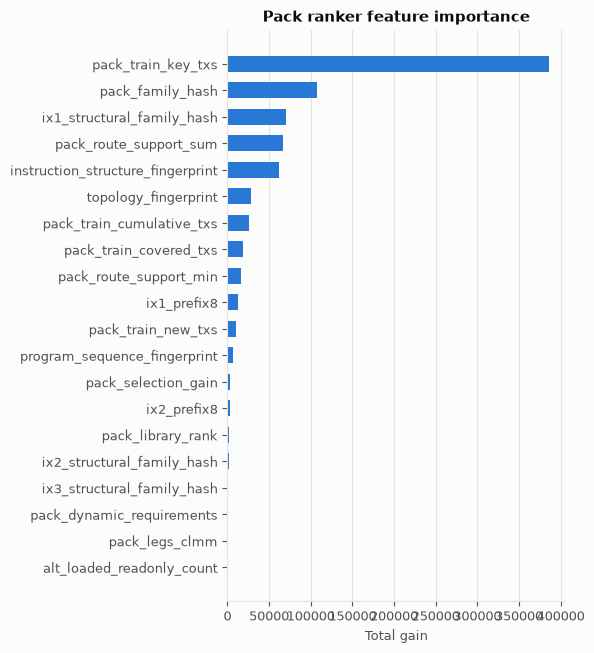

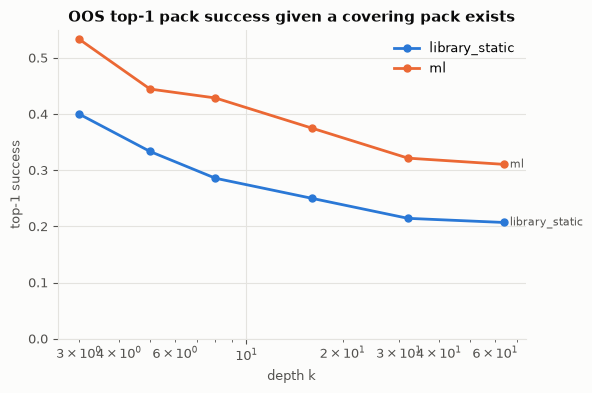

In [9]:
RESULTS["ranker_importance"] = models.importance(ranker)[:40]
plots.importance(RESULTS["ranker_importance"], "Pack ranker feature importance", PLOTS / "ranker_importance.png")
t = ranking.filter(pl.col("split") == "test")
plots.lines({sc: (t.filter(pl.col("scorer") == sc)["depth"].to_list(), t.filter(pl.col("scorer") == sc)["top1"].to_list())
             for sc in ("library_static", "ml") if t.filter(pl.col("scorer") == sc).height},
            "OOS top-1 pack success given a covering pack exists", "depth k", "top-1 success", PLOTS / "ranking_top1_vs_k.png", logx=True);

## 6. Decision policies at matched send budgets

All policies use the same relevance gate and arb classifier. They differ in how they pick sends and packs:

| policy | decision | pack order |
|---|---|---|
| `legacy_two_stage` | arb ≥ t | legacy builder rank (legacy catalog) |
| `library_two_stage` | arb ≥ t | library rank |
| `ml_two_stage` | arb ≥ t | learned ranker |
| `joint` | max over packs of P(arb) · P(pack) ≥ t | learned ranker |

For each send budget (sends per chain hour) and policy, the threshold is fitted on **validation**, then applied
unchanged to test. Depth k and live top-L are reported over a grid. The validation-best combination per budget is
the operating point.

In [10]:
WEIGHT = policy.sample_weight(tx, PPM)
cols_tx = ["master_tx_id", "arb_target", "arb_label", "encode_status", GATE, "arb_score", "pair_sample", "min_cover_rank_live",
           "n_profitable_routes_seen_in_train", "split"]
tx_eval = tx.select(cols_tx)
if legacy is not None:
    tx_legacy = tx_eval.drop("min_cover_rank_live").join(
        data.load_transactions(legacy).select("master_tx_id", "min_cover_rank_live"), on="master_tx_id")

POLICIES = {   # name -> (rule, pair frame, pack score, joint prob column)
    "library_two_stage": ("two_stage", rf, "library_static", None),
    "ml_two_stage": ("two_stage", rf, "ml", None),
    "joint": ("joint", rf, "ml", "ml"),
}
if legacy is not None:
    POLICIES = {"legacy_two_stage": ("two_stage", legacy_pairs, "legacy_static", None), **POLICIES}

def frame(name, split, depth, L):
    rule, pr, score, joint = POLICIES[name]
    t = (tx_legacy if name.startswith("legacy") else tx_eval).filter(pl.col("split") == split)
    return policy.per_tx(t, pr.filter(pl.col("split") == split), score, depth, L, joint)

rows = []
for name, (rule, *_rest) in POLICIES.items():
    for depth in (DEPTHS if not name.startswith("legacy") else [3]):
        for L in LIVE_TOP:
            dv, dt = frame(name, "val", depth, L), frame(name, "test", depth, L)
            sv = policy.decision_score(dv, rule).to_numpy()
            wv = dv.select(WEIGHT).to_series().to_numpy()
            for budget in BUDGETS:
                t = policy.threshold_for_budget(sv, wv, budget * HOURS["val"])
                v = policy.evaluate(dv, rule, t, HOURS["val"], WEIGHT)
                o = policy.evaluate(dt, rule, t, HOURS["test"], WEIGHT)
                rows.append({"policy": name, "depth": depth, "L": L, "budget_per_hour": budget, "threshold": t,
                             "val_sends_per_hour": v["sends_per_chain_hour"], "val_end_to_end_recall": v["end_to_end_recall"],
                             "val_succeeded": v["succeeded"],
                             **{f"test_{k}": o[k] for k in ("sends_per_chain_hour", "precision_arb", "precision_capture",
                                                            "positive_recall", "availability", "topL_success_given_sent_and_available",
                                                            "end_to_end_recall", "end_to_end_recall_ci", "succeeded", "unknown_share_of_sends")},
                             **{f"test_missed_{k}": n for k, n in o["missed"].items()}})
grid = pl.DataFrame(rows)
RESULTS["policy_grid"] = rows
# Operating point per (policy, budget): the depth / L with the most validation successes (ties: smaller L, then smaller depth).
best = (grid.sort(["policy", "budget_per_hour", "val_succeeded", "L", "depth"], descending=[False, False, True, False, False])
            .group_by(["policy", "budget_per_hour"], maintain_order=True).first())
RESULTS["operating_points"] = best.to_dicts()
best.select("policy", "budget_per_hour", "depth", "L", "threshold", "val_succeeded", "test_sends_per_chain_hour",
            "test_precision_arb", "test_precision_capture", "test_positive_recall", "test_availability",
            "test_topL_success_given_sent_and_available", "test_succeeded", "test_end_to_end_recall", "test_end_to_end_recall_ci",
            "test_unknown_share_of_sends").sort("budget_per_hour", "policy")

policy,budget_per_hour,depth,L,threshold,val_succeeded,test_sends_per_chain_hour,test_precision_arb,test_precision_capture,test_positive_recall,test_availability,test_topL_success_given_sent_and_available,test_succeeded,test_end_to_end_recall,test_end_to_end_recall_ci,test_unknown_share_of_sends
str,i64,i64,i64,f64,i64,f64,f64,f64,f64,f64,f64,i64,f64,list[f64],f64
"""joint""",250,3,1,0.61763,0,86.921529,null,null,0.0,0.194805,null,0,0.0,"[3.4694e-18, 0.04752]",1.0
"""legacy_two_stage""",250,3,3,0.996898,1,86.921529,null,null,0.0,0.220779,null,0,0.0,"[3.4694e-18, 0.04752]",1.0
"""library_two_stage""",250,3,2,0.996898,1,86.921529,null,null,0.0,0.194805,null,0,0.0,"[3.4694e-18, 0.04752]",1.0
"""ml_two_stage""",250,3,1,0.996898,1,86.921529,null,null,0.0,0.194805,null,0,0.0,"[3.4694e-18, 0.04752]",1.0
"""joint""",1000,3,1,0.562907,1,988.732394,1.0,1.0,0.012987,0.194805,1.0,1,0.012987,"[0.002296, 0.069964]",0.996337
"""legacy_two_stage""",1000,3,3,0.994171,1,550.503018,null,null,0.0,0.220779,null,0,0.0,"[3.4694e-18, 0.04752]",1.0
"""library_two_stage""",1000,3,2,0.994171,1,550.503018,null,null,0.0,0.194805,null,0,0.0,"[3.4694e-18, 0.04752]",1.0
"""ml_two_stage""",1000,3,1,0.994171,1,550.503018,null,null,0.0,0.194805,null,0,0.0,"[3.4694e-18, 0.04752]",1.0
"""joint""",4000,3,1,0.313034,2,3842.655936,0.4,0.4,0.025974,0.194805,1.0,2,0.025974,"[0.007152, 0.089848]",0.995287


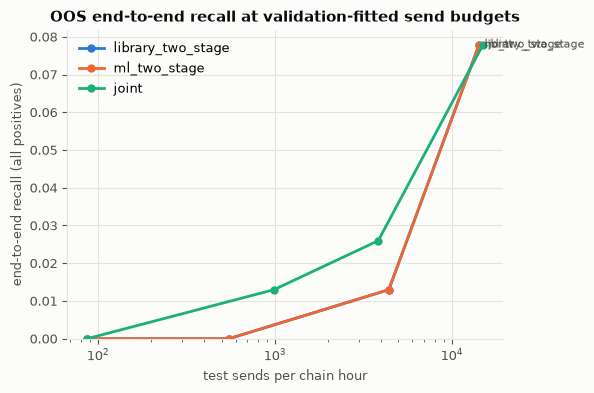

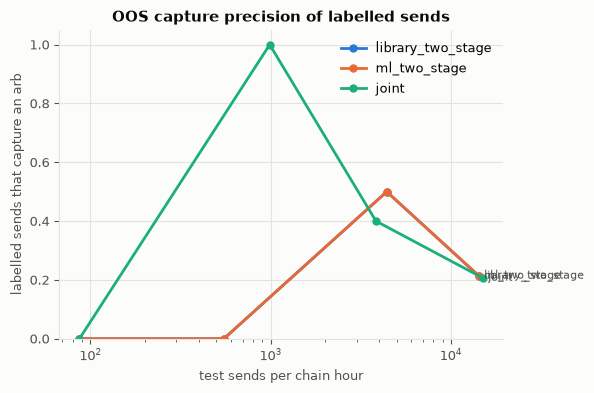

In [11]:
plots.lines({p: (best.filter(pl.col("policy") == p)["test_sends_per_chain_hour"].to_list(),
                 best.filter(pl.col("policy") == p)["test_end_to_end_recall"].to_list()) for p in POLICIES if p != "legacy_two_stage"},
            "OOS end-to-end recall at validation-fitted send budgets", "test sends per chain hour", "end-to-end recall (all positives)",
            PLOTS / "recall_vs_sends.png", logx=True)
plots.lines({p: (best.filter(pl.col("policy") == p)["test_sends_per_chain_hour"].to_list(),
                 best.filter(pl.col("policy") == p)["test_precision_capture"].fill_null(0).to_list()) for p in POLICIES if p != "legacy_two_stage"},
            "OOS capture precision of labelled sends", "test sends per chain hour", "labelled sends that capture an arb",
            PLOTS / "precision_vs_sends.png", logx=True);

## 7. Failure decomposition and conditional results

Every OOS positive transaction, at each policy's operating point, is assigned one outcome in pipeline order:
encoder cannot parse it (zero with framed-tx-v2; non-zero only for datasets built with framed-tx-v1) → relevance-gate miss → classifier/threshold miss
→ no covering candidate pack → pack-ranking miss → success.

subset,joint,legacy_two_stage,library_two_stage,ml_two_stage
str,f64,f64,f64,f64
"""all""",0.012987,0.0,0.0,0.0
"""covering pack exists""",0.066667,0.0,0.0,0.0
"""route seen in train""",0.018519,0.0,0.0,0.0
"""route not seen in train""",0.0,0.0,0.0,0.0
"""raw-visible (gate passes)""",0.015152,0.0,0.0,0.0
"""ALT-only (gate fails)""",0.0,0.0,0.0,0.0
"""encoder cannot parse (v1 format)""",null,null,null,null


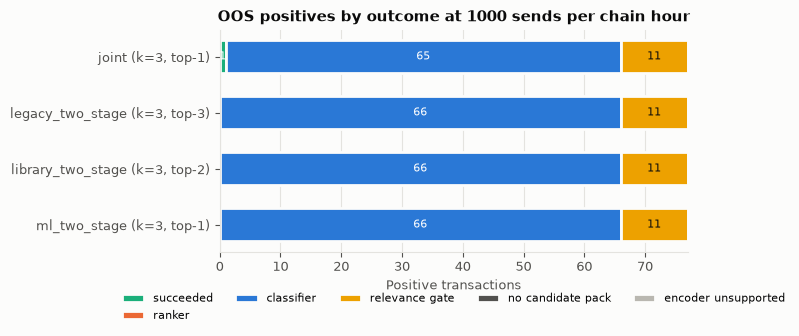

In [12]:
FOCUS_BUDGET = 1000
fb = best.filter(pl.col("budget_per_hour") == FOCUS_BUDGET)
bars = [{"label": f"{r['policy']} (k={r['depth']}, top-{r['L']})", "succeeded": r["test_succeeded"],
         "encoder_unsupported": r["test_missed_encoder_unsupported"],
         "relevance_gate": r["test_missed_relevance_gate"], "classifier": r["test_missed_threshold"],
         "no_candidate_pack": r["test_missed_no_covering_pack"], "ranker": r["test_missed_ranking"]} for r in fb.iter_rows(named=True)]
plots.miss_breakdown(bars, f"OOS positives by outcome at {FOCUS_BUDGET} sends per chain hour", PLOTS / "failure_decomposition.png")
cond = []
for r in fb.iter_rows(named=True):
    rule = POLICIES[r["policy"]][0]
    d = frame(r["policy"], "test", r["depth"], r["L"])
    for row in policy.conditional_success(d, rule, r["threshold"]).iter_rows(named=True):
        cond.append({"policy": r["policy"], **row})
cond = pl.DataFrame(cond)
RESULTS["conditional"] = cond.to_dicts()
cond.pivot(on="policy", index="subset", values="rate")

In [13]:
h = {r["policy"]: r for r in fb.iter_rows(named=True)}
fmt = lambda x: "n/a" if x is None else f"{x:.2f}"
lines = [f"**At {FOCUS_BUDGET} sends per chain hour (thresholds fitted on validation), OOS test:**", ""]
for p, r in h.items():
    lines.append(f"- `{p}` (k={r['depth']}, top-{r['L']}): {r['test_succeeded']}/{r['test_succeeded'] + sum(r[c] for c in r if c.startswith('test_missed_'))} positives captured "
                 f"(end-to-end recall {fmt(r['test_end_to_end_recall'])}, CI {r['test_end_to_end_recall_ci']}), "
                 f"capture precision {fmt(r['test_precision_capture'])}, {r['test_sends_per_chain_hour']:.0f} sends/h.")
lines += ["", f"Learned ranker kept: **{KEEP_ML}**. Route-recurrence ceiling on test: "
          f"{ceiling.filter(pl.col('split') == 'test')['ceiling'][0]:.2f} of positives have any profitable RouteId seen in training."]
display(Markdown("\n".join(lines)))
RESULTS["headline"] = lines

**At 1000 sends per chain hour (thresholds fitted on validation), OOS test:**

- `joint` (k=3, top-1): 1/77 positives captured (end-to-end recall 0.01, CI [0.0022961581721549496, 0.06996366845176145]), capture precision 1.00, 989 sends/h.
- `legacy_two_stage` (k=3, top-3): 0/77 positives captured (end-to-end recall 0.00, CI [3.469446951953614e-18, 0.047520088667220836]), capture precision n/a, 551 sends/h.
- `library_two_stage` (k=3, top-2): 0/77 positives captured (end-to-end recall 0.00, CI [3.469446951953614e-18, 0.047520088667220836]), capture precision n/a, 551 sends/h.
- `ml_two_stage` (k=3, top-1): 0/77 positives captured (end-to-end recall 0.00, CI [3.469446951953614e-18, 0.047520088667220836]), capture precision n/a, 551 sends/h.

Learned ranker kept: **True**. Route-recurrence ceiling on test: 0.70 of positives have any profitable RouteId seen in training.

## 8. Artifacts

In [14]:
import shutil
sha = models.sha256_file
common = {"prepared_manifest_sha256": sha(PREPARED / "manifest.json"), "split_boundaries": bounds,
          "feature_schema": prep.feature_manifest["feature_schema"], "pack_feature_schema": prep.feature_manifest["pack_feature_schema"],
          "pack_catalog": {k: pw[k] for k in ("catalog_schema", "count", "train_master_tx_id_min", "train_master_tx_id_max")},
          "relevance": {k: M["relevance"][k] for k in ("schema", "universe_digest", "rule")}}
arb_meta = models.save_model(arb, arb_enc, RUN_DIR / "models", "arb_classifier", models.ARB_PARAMS,
                             {**common, "target": "POSITIVE=1, CERTIFIED_NEGATIVE=0, UNKNOWN excluded", "applies_after_gate": GATE})
rk_meta = models.save_model(ranker, rk_enc, RUN_DIR / "models", "pack_ranker", models.RANKER_PARAMS,
                            {**common, "target": "pack covers a profitable RouteId", "training_rows": "live pairs of POSITIVE train transactions",
                             "kept": KEEP_ML})
ops = [{k: r[k] for k in ("policy", "budget_per_hour", "depth", "L", "threshold")} for r in best.iter_rows(named=True)]
(RUN_DIR / "operating_points.json").write_text(json.dumps(ops, indent=1))
shutil.copy(PREPARED / "feature_manifest.json", RUN_DIR / "feature_manifest.json")
(RUN_DIR / "split_boundaries.json").write_text(json.dumps({"slots": bounds, "master_ids": ids, "library_window": pw["train_master_tx_id_max"]}, indent=1))
preds = RUN_DIR / "predictions"; preds.mkdir(exist_ok=True)
tx.filter(pl.col("split") != "train").select(cols_tx).write_parquet(preds / "arb_predictions.parquet")
rf.filter((pl.col("split") != "train") & pl.col("eligible_live")).select(
    "master_tx_id", "split", "pack_id", "pack_rank", "arb_label", "pack_target", "ml", "ml_static_only").write_parquet(preds / "pack_predictions.parquet")
(RUN_DIR / "metrics.json").write_text(json.dumps(RESULTS, indent=1, default=str))
artifacts = sorted(p for p in RUN_DIR.rglob("*") if p.is_file() and p.name != "experiment_manifest.json")
manifest = {
    "experiment": EXPERIMENT,
    "protocol": "library built from train master ids only and frozen; thresholds, depth and top-L from validation; test evaluated once",
    "prepared_dataset": {"path": str(PREPARED), "manifest_sha256": common["prepared_manifest_sha256"], "schemas": M["schemas"],
                         "packs": {k: v for k, v in pw.items() if k != "library"}, "library_manifest": pw.get("library"),
                         "inputs": M["inputs"], "raw_source": M["raw_source"], "outputs": M["outputs"],
                         "provenance_files": {k: v["sha256"] for k, v in M["provenance"].items()}},
    "legacy_dataset": None if legacy is None else {"path": str(legacy.root), "manifest_sha256": sha(legacy.root / "manifest.json")},
    "models": {"arb_classifier": arb_meta, "pack_ranker": rk_meta},
    "environment": models.environment(),
    "artifacts": [{"path": str(p.relative_to(RUN_DIR)).replace(os.sep, "/"), "sha256": sha(p)} for p in artifacts],
}
(RUN_DIR / "experiment_manifest.json").write_text(json.dumps(manifest, indent=1, default=str))
b, e, meta = models.load_model(RUN_DIR / "models", "pack_ranker")
assert meta["feature_order"] == prep.tx_features + prep.pack_features
print(RUN_DIR); print("\n".join(a["path"] for a in manifest["artifacts"]))

C:\Users\louis\Desktop\the-firm-offline\ml\runs\v1-p045-library-ftx2
feature_manifest.json
metrics.json
models/arb_classifier.encoder.json
models/arb_classifier.json
models/arb_classifier.txt
models/pack_ranker.encoder.json
models/pack_ranker.json
models/pack_ranker.txt
operating_points.json
plots/arb_pr_curve.png
plots/availability_vs_k.png
plots/failure_decomposition.png
plots/precision_vs_sends.png
plots/ranker_importance.png
plots/ranking_top1_vs_k.png
plots/recall_vs_sends.png
predictions/arb_predictions.parquet
predictions/pack_predictions.parquet
split_boundaries.json


### Caveats
- **This is pipeline validation.** The 10k-slot window has about 40 OOS positives. Read the confidence intervals,
  and do not tune anything to these numbers. The weekly dataset is the real test.
- **Joint score.** P(pack) comes from a ranker trained on positive transactions only. The product is therefore
  P(arb) · P(cover | arb), not a separately calibrated joint probability.
- **Live volume.** It is estimated from the deterministic UNKNOWN pair sample (`unknown_pair_ppm`) and weighted by
  1/rate. Failed transactions and transactions outside the master set are not in the population.
- **Library metadata.** The train_meta pack features come from the library's training window. They are valid only
  because the notebook asserts that window ends before validation.